# Water Level Prediction Pipeline v2
## BBWS Bengawan Solo — TMA Prediction

Improved pipeline with:
- **Target lag features** (leak-free) — most powerful features
- **Antecedent Precipitation Index (API)** — exponentially weighted rainfall
- **Wet/dry spell detection**
- **Enhanced pressure/humidity difference features**
- **Removed target leakage** (station_mean/min/max_tma removed)
- **Tuned hyperparameters** for better generalization
- **Holdout-based early stopping** for full training
- **Stacking ensemble** with inverse-RMSE weighting
- **Per-station diagnostic** reporting


In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import set_seed, reduce_mem_usage
set_seed()
print(f'Project root: {PROJECT_ROOT}')


Project root: d:\Lomba\SSDS\Repo\SSDS_Dikeri-Leon\fayadh


---
## Step 1: Load & Preprocess

Load all datasets, clean environment data, aggregate hourly to 6-hourly, extract river features, merge into master datasets.


In [2]:
from src.preprocess import run_preprocessing

master_train, master_test = run_preprocessing()

print('\n' + '='*60)
print('Master Train:', master_train.shape)
print('Master Test: ', master_test.shape)
print('='*60)


Loading datasets...
  train: (84396, 3)
  test: (21780, 3)
  env: (888480, 27)
  coord: (30, 3)
  river: (836472, 15)

Cleaning environment data...
Cleaned env: (888480, 27), remaining NaN: 0

Aggregating environment data to 6-hourly...
Aggregated env: (111060, 26)

Extracting river features...
River features extracted for 30 stations.

Building spatial features...
Spatial features: (30, 16)

Merging master train...
Master shape: (84396, 42)

Merging master test...
Master shape: (21780, 42)

Master Train: (84396, 42)
Master Test:  (21780, 42)


In [3]:
# Reduce memory usage
master_train = reduce_mem_usage(master_train)
master_test = reduce_mem_usage(master_test)


Memory: 26.6 MB -> 14.6 MB (45.0% reduction)
Memory: 7.6 MB -> 4.5 MB (39.9% reduction)


---
## Step 2: Feature Engineering

Build all features: time, cyclic, target lags (leak-free), env lags, rolling, difference, cumulative, API, wet/dry spells, station encoding.

> **Important**: Target lags use only PAST values (shift). Station baselines are NO LONGER computed from target to avoid leakage.


In [4]:
from src.feature_engineering import build_all_features, get_feature_columns, get_categorical_features

# Save a copy of master_test BEFORE feature engineering (needed for test FE later)
master_test_raw = master_test.copy()
# Also save a copy of master_train BEFORE FE (needed for test history)
master_train_raw = master_train.copy()

# Build features for TRAIN
master_train = build_all_features(master_train, is_train=True)


Building features...
  [OK] Time features
  [OK] Cyclic features
  [OK] Station encoding
  [OK] Regional features
  [OK] Difference features
  [OK] Cumulative rainfall
  [OK] Antecedent Precipitation Index
  [OK] Environment lags
  [OK] Environment rolling
  [OK] Climate rolling
  [OK] Wet/dry spells
  [OK] Interaction features
  [OK] Target lags (leak-free)
  [OK] Target rolling (leak-free)
  [OK] Target diff (leak-free)
Final shape: (84396, 153)


In [5]:
from src.inference import build_test_features_with_history

# Build test features using train as history for lag/rolling
# This concatenates ALL train + test, builds features, then splits back
# Target lags in test will use the last known train target values
master_test_featured = build_test_features_with_history(
    master_train=master_train_raw,
    master_test=master_test_raw,
    build_features_fn=build_all_features,
)


Building features...
  [OK] Time features
  [OK] Cyclic features
  [OK] Station encoding
  [OK] Regional features
  [OK] Difference features
  [OK] Cumulative rainfall
  [OK] Antecedent Precipitation Index
  [OK] Environment lags
  [OK] Environment rolling
  [OK] Climate rolling
  [OK] Wet/dry spells
  [OK] Interaction features
  [OK] Target lags (leak-free)
  [OK] Target rolling (leak-free)
  [OK] Target diff (leak-free)
Final shape: (106176, 155)

Target lag coverage in test set:
  tma_lag_1: 30/21780 (0.1%) non-NaN
  tma_lag_2: 60/21780 (0.3%) non-NaN
  tma_lag_3: 90/21780 (0.4%) non-NaN
  tma_lag_6: 180/21780 (0.8%) non-NaN
  tma_lag_9: 270/21780 (1.2%) non-NaN
  tma_lag_12: 360/21780 (1.7%) non-NaN
Test features built: (21780, 154)


In [6]:
# Get feature columns (excluding target, datetime, station name, id)
feature_cols = get_feature_columns(master_train)
cat_features = get_categorical_features(feature_cols)

print(f'Total features: {len(feature_cols)}')
print(f'Categorical features: {cat_features}')
print(f'\nFeature list:')
for i, f in enumerate(sorted(feature_cols)):
    print(f'  {i+1:3d}. {f}')


Total features: 149
Categorical features: ['landcover_class', 'main_river_id', 'hydrobasin_id', 'station_cluster', 'hour', 'month', 'quarter', 'dayofweek', 'is_weekend', 'station_encoded', 'pressure_falling']

Feature list:
    1. api_085
    2. api_085_x_upstream
    3. api_095
    4. api_095_x_upstream
    5. built_surface_m2
    6. catchment_local
    7. cloud_cover_pct
    8. day
    9. dayofweek
   10. dayofyear
   11. dayofyear_cos
   12. dayofyear_sin
   13. delta_humidity_1
   14. delta_humidity_3
   15. delta_pressure_1
   16. delta_pressure_3
   17. delta_rain_1
   18. delta_soil_0_7_1
   19. delta_temp_1
   20. dew_point_c
   21. dist_to_ocean
   22. dist_to_source
   23. dry_spell_length
   24. hour
   25. hour_cos
   26. hour_sin
   27. humidity_lag_1
   28. humidity_lag_3
   29. humidity_pct
   30. hydrobasin_id
   31. is_weekend
   32. landcover_class
   33. latitude
   34. longitude
   35. main_river_id
   36. mjo_active
   37. mjo_active_roll_mean_120
   38. mjo_active

In [7]:
# Check NaN in features (lags will have NaN for early rows - expected, GBDT handles it)
nan_counts = master_train[feature_cols].isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

print(f'Features with NaN: {len(nan_counts)}')
if len(nan_counts) > 0:
    print(nan_counts.head(20))

# Verify no target leakage: station_mean_tma should NOT exist
leaky_cols = [c for c in feature_cols if 'station_mean' in c or 'station_min' in c or 'station_max' in c]
if leaky_cols:
    print(f'\nWARNING: Potential leaky features found: {leaky_cols}')
else:
    print(f'\nNo target leakage detected in feature columns.')


Features with NaN: 80
tma_lag_12                     360
tma_lag_9                      270
rainfall_mm_lag_6              180
rainfall_openmeteo_mm_lag_6    180
tma_lag_6                      180
tma_diff_6                     180
rainfall_mm_lag_3               90
delta_pressure_3                90
tma_diff_3                      90
humidity_lag_3                  90
rainfall_openmeteo_mm_lag_3     90
delta_humidity_3                90
tma_lag_3                       90
tma_roll_std_12                 60
tma_roll_std_3                  60
tma_lag_2                       60
tma_roll_std_6                  60
tma_roll_std_24                 60
rain_cumsum_168h                30
rain_cumsum_336h                30
dtype: int64

No target leakage detected in feature columns.


---
## Step 3: Validation Setup

Walk-forward cross-validation with 3 folds.


In [8]:
from src.validation import TimeSeriesCV

cv = TimeSeriesCV()
print(cv)


TimeSeriesCV with 3 folds:
  Fold 0: train -> 2024-06-30 18:00:00, valid: 2024-07-01 06:00:00 -> 2024-12-31 18:00:00
  Fold 1: train -> 2024-12-31 18:00:00, valid: 2025-01-01 06:00:00 -> 2025-06-30 18:00:00
  Fold 2: train -> 2025-06-30 18:00:00, valid: 2025-07-01 06:00:00 -> 2025-09-18 18:00:00


---
## Step 4: Model Training & Cross-Validation

### 4.1 LightGBM (Huber loss for robustness)


Fold 0: train=46772 (2023-01-01 -> 2024-06-30), valid=16425 (2024-07-01 -> 2024-12-31)
  [Feature Selection] Running fast fit for lightgbm...
  [Feature Selection] Selected 101 / 149 features.

Fold 0 — lightgbm
  Train: 46772 rows, Valid: 16425 rows
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 0.692027	valid's rmse: 1.78182
[400]	train's rmse: 0.603101	valid's rmse: 1.73518
[600]	train's rmse: 0.563757	valid's rmse: 1.71687
[800]	train's rmse: 0.539294	valid's rmse: 1.70738
[1000]	train's rmse: 0.52282	valid's rmse: 1.70168
[1200]	train's rmse: 0.509393	valid's rmse: 1.69861
[1400]	train's rmse: 0.497668	valid's rmse: 1.69538
[1600]	train's rmse: 0.486715	valid's rmse: 1.69326
[1800]	train's rmse: 0.477481	valid's rmse: 1.69226
[2000]	train's rmse: 0.468432	valid's rmse: 1.69062
[2200]	train's rmse: 0.459669	valid's rmse: 1.68931
[2400]	train's rmse: 0.451333	valid's rmse: 1.68872
[2600]	train's rmse: 0.443581	valid's rmse: 1.68805
[2800]	train's r

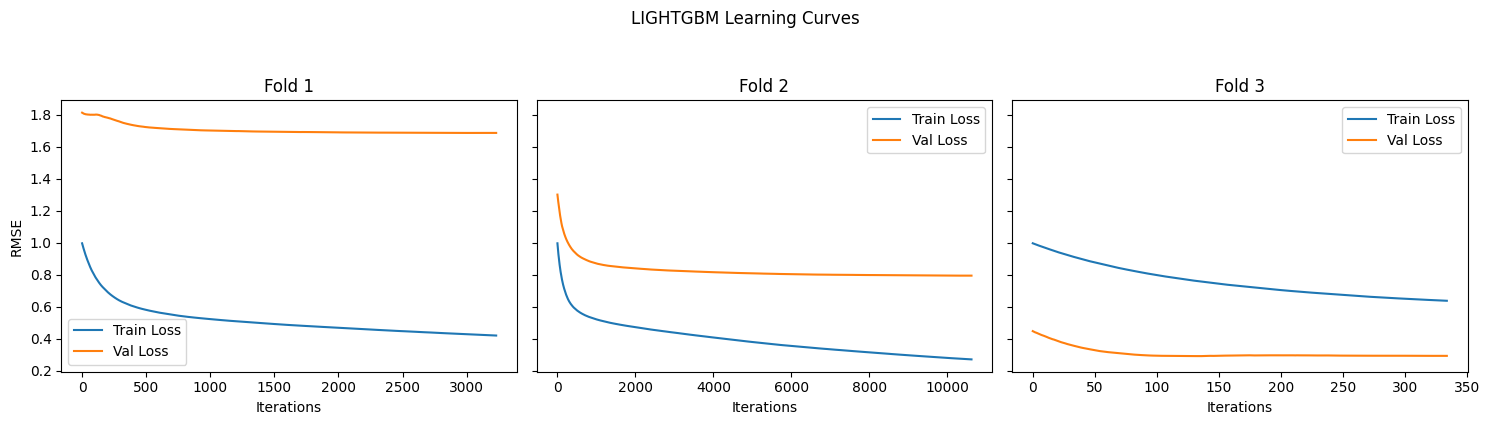

In [9]:
from src.train import run_experiment

results_lgb = run_experiment(
    exp_id='001_v2',
    model_name='lightgbm',
    df=master_train,
    feature_cols=feature_cols,
    feature_desc='All_v2_target_lags_API_no_leakage',
    cv=cv,
    categorical_features=cat_features,
    save_model=True,
    verbose=True
)


### 4.2 CatBoost


Fold 0: train=46772 (2023-01-01 -> 2024-06-30), valid=16425 (2024-07-01 -> 2024-12-31)
  [Feature Selection] Running fast fit for catboost...


You should provide test set for use best model. use_best_model parameter has been switched to false value.


0:	learn: 0.9864030	total: 347ms	remaining: 34.4s
99:	learn: 0.5034763	total: 22.1s	remaining: 0us
  [Feature Selection] Selected 103 / 149 features.

Fold 0 — catboost
  Train: 46772 rows, Valid: 16425 rows
0:	learn: 0.9854036	test: 1.8146790	best: 1.8146790 (0)	total: 51.2ms	remaining: 8m 32s
200:	learn: 0.3762318	test: 1.6642692	best: 1.6641129 (197)	total: 13.4s	remaining: 10m 52s
400:	learn: 0.2683953	test: 1.6394440	best: 1.6387163 (395)	total: 26.2s	remaining: 10m 26s
600:	learn: 0.2134159	test: 1.6310220	best: 1.6295574 (576)	total: 40.5s	remaining: 10m 32s
800:	learn: 0.1773776	test: 1.6239668	best: 1.6238887 (742)	total: 53.4s	remaining: 10m 13s
1000:	learn: 0.1515047	test: 1.6205789	best: 1.6196797 (966)	total: 1m 7s	remaining: 10m 9s
1200:	learn: 0.1329054	test: 1.6195130	best: 1.6190024 (1098)	total: 1m 20s	remaining: 9m 50s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1.619002357
bestIteration = 1098

Shrink model to first 1099 iterations.
[Fold 0] R

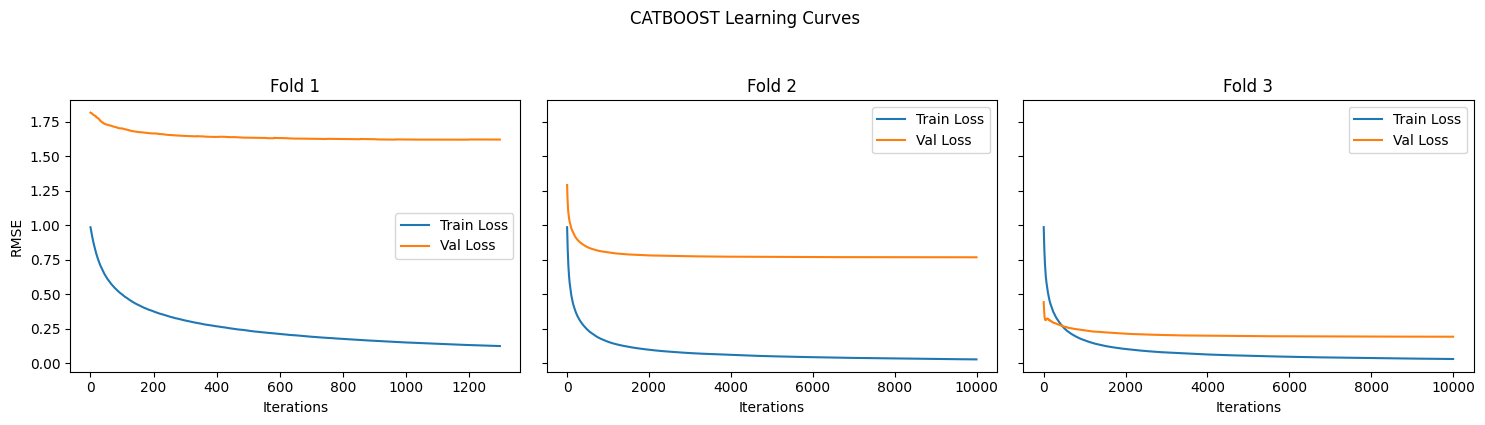

In [10]:
results_cb = run_experiment(
    exp_id='002_v2',
    model_name='catboost',
    df=master_train,
    feature_cols=feature_cols,
    feature_desc='All_v2_target_lags_API_no_leakage',
    cv=cv,
    categorical_features=cat_features,
    save_model=True,
    verbose=True
)


### 4.3 XGBoost


Fold 0: train=46772 (2023-01-01 -> 2024-06-30), valid=16425 (2024-07-01 -> 2024-12-31)
  [Feature Selection] Running fast fit for xgboost...
  [Feature Selection] Selected 104 / 149 features.

Fold 0 — xgboost
  Train: 46772 rows, Valid: 16425 rows
[Fold 0] RMSE: 1.885992 | MAE: 0.717267 | R2: 0.998371
  Worst 5 stations:
    Gunungsari: RMSE=10.0111
    Bojonegoro - Kali Kethek: RMSE=2.8493
    Wonogiri Dam: RMSE=2.1557
    Napel: RMSE=1.9298
    Ketonggo: RMSE=1.6563
Fold 1: train=63197 (2023-01-01 -> 2024-12-31), valid=14015 (2025-01-01 -> 2025-06-30)

Fold 1 — xgboost
  Train: 63197 rows, Valid: 14015 rows
[Fold 1] RMSE: 1.233485 | MAE: 0.474824 | R2: 0.999302
  Worst 5 stations:
    Jurug: RMSE=3.5618
    Peren: RMSE=2.3112
    Bojonegoro - Kali Kethek: RMSE=2.2814
    Kedungupit: RMSE=2.0292
    Floodway Bridge C: RMSE=1.9951
Fold 2: train=77212 (2023-01-01 -> 2025-06-30), valid=7184 (2025-07-01 -> 2025-09-18)

Fold 2 — xgboost
  Train: 77212 rows, Valid: 7184 rows
[Fold 2] RMSE:

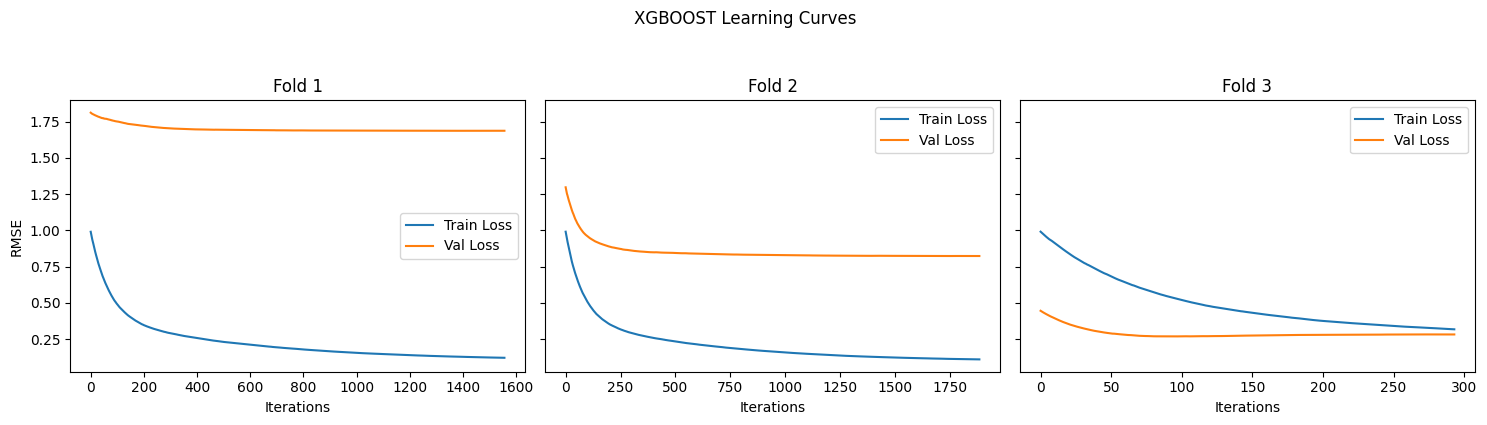

In [11]:
results_xgb = run_experiment(
    exp_id='003_v2',
    model_name='xgboost',
    df=master_train,
    feature_cols=feature_cols,
    feature_desc='All_v2_target_lags_API_no_leakage',
    cv=cv,
    categorical_features=cat_features,
    save_model=True,
    verbose=True
)


### 4.4 Random Forest


In [12]:
results_rf = run_experiment(
    exp_id='004_v2',
    model_name='random_forest',
    df=master_train,
    feature_cols=feature_cols,
    feature_desc='All_v2_target_lags_API_no_leakage',
    cv=cv,
    categorical_features=cat_features,
    save_model=True,
    verbose=True
)


Fold 0: train=46772 (2023-01-01 -> 2024-06-30), valid=16425 (2024-07-01 -> 2024-12-31)
  [Feature Selection] Running fast fit for random_forest...
  [Feature Selection] Selected 104 / 149 features.

Fold 0 — random_forest
  Train: 46772 rows, Valid: 16425 rows
[Fold 0] RMSE: 1.785049 | MAE: 0.667127 | R2: 0.998541
  Worst 5 stations:
    Gunungsari: RMSE=10.3389
    Floodway Bridge C: RMSE=1.3836
    Wonogiri Dam: RMSE=1.3224
    Bojonegoro - Kali Kethek: RMSE=1.0949
    Ketonggo: RMSE=0.9901
Fold 1: train=63197 (2023-01-01 -> 2024-12-31), valid=14015 (2025-01-01 -> 2025-06-30)

Fold 1 — random_forest
  Train: 63197 rows, Valid: 14015 rows
[Fold 1] RMSE: 1.101184 | MAE: 0.499699 | R2: 0.999444
  Worst 5 stations:
    Jurug: RMSE=3.7971
    Floodway Bridge C: RMSE=1.7832
    Peren: RMSE=1.7618
    Bojonegoro - Kali Kethek: RMSE=1.5414
    Wonogiri Dam: RMSE=1.4343
Fold 2: train=77212 (2023-01-01 -> 2025-06-30), valid=7184 (2025-07-01 -> 2025-09-18)

Fold 2 — random_forest
  Train: 77212

MemoryError: could not allocate 1048576 bytes

### 4.5 Bagging


In [ ]:
import importlib
import src.config
import src.models
import src.train

importlib.reload(src.config)
importlib.reload(src.models)
importlib.reload(src.train)

print("Konfigurasi dan Model berhasil di-reload!")

Konfigurasi dan Model berhasil di-reload!


In [ ]:
results_bagging = run_experiment(
    exp_id='005_v2',
    model_name='bagging',
    df=master_train,
    feature_cols=feature_cols,
    feature_desc='All_v2_target_lags_API_no_leakage',
    cv=cv,
    categorical_features=cat_features,
    save_model=True,
    verbose=True
)


Fold 0: train=46772 (2023-01-01 -> 2024-06-30), valid=16425 (2024-07-01 -> 2024-12-31)
  [Feature Selection] Running fast fit for bagging...
  [Feature Selection] Selected 104 / 149 features.

Fold 0 — bagging
  Train: 46772 rows, Valid: 16425 rows
[Fold 0] RMSE: 1.839716 | MAE: 0.713128 | R2: 0.998450
  Worst 5 stations:
    Gunungsari: RMSE=10.4285
    Floodway Bridge C: RMSE=1.7703
    Bojonegoro - Kali Kethek: RMSE=1.5003
    Ketonggo: RMSE=1.1822
    Wonogiri Dam: RMSE=1.1541
Fold 1: train=63197 (2023-01-01 -> 2024-12-31), valid=14015 (2025-01-01 -> 2025-06-30)

Fold 1 — bagging
  Train: 63197 rows, Valid: 14015 rows
[Fold 1] RMSE: 1.219421 | MAE: 0.580953 | R2: 0.999318
  Worst 5 stations:
    Jurug: RMSE=3.8272
    Bojonegoro - Kali Kethek: RMSE=2.2250
    Peren: RMSE=2.0411
    Napel: RMSE=1.8601
    Floodway Bridge C: RMSE=1.7484
Fold 2: train=77212 (2023-01-01 -> 2025-06-30), valid=7184 (2025-07-01 -> 2025-09-18)

Fold 2 — bagging
  Train: 77212 rows, Valid: 7184 rows
[Fold 2

---
## Step 5: Model Comparison


In [13]:
from src.train import compare_models

all_results = {
    'LightGBM': results_lgb,
    'CatBoost': results_cb,
    'XGBoost': results_xgb,
    # 'Random Forest': results_rf
}

comparison = compare_models(all_results)
display(comparison)


,model,rmse,rmse_std,mae,mae_std,r2,r2_std,time_s
0,LightGBM,1.114720,0.558542,0.438361,0.151823,0.999288,0.000547,316.0
1,CatBoost,1.134663,0.558477,0.470804,0.203471,0.999267,0.000541,2234.9
2,XGBoost,1.178584,0.601264,0.481320,0.190054,0.999198,0.000637,192.8


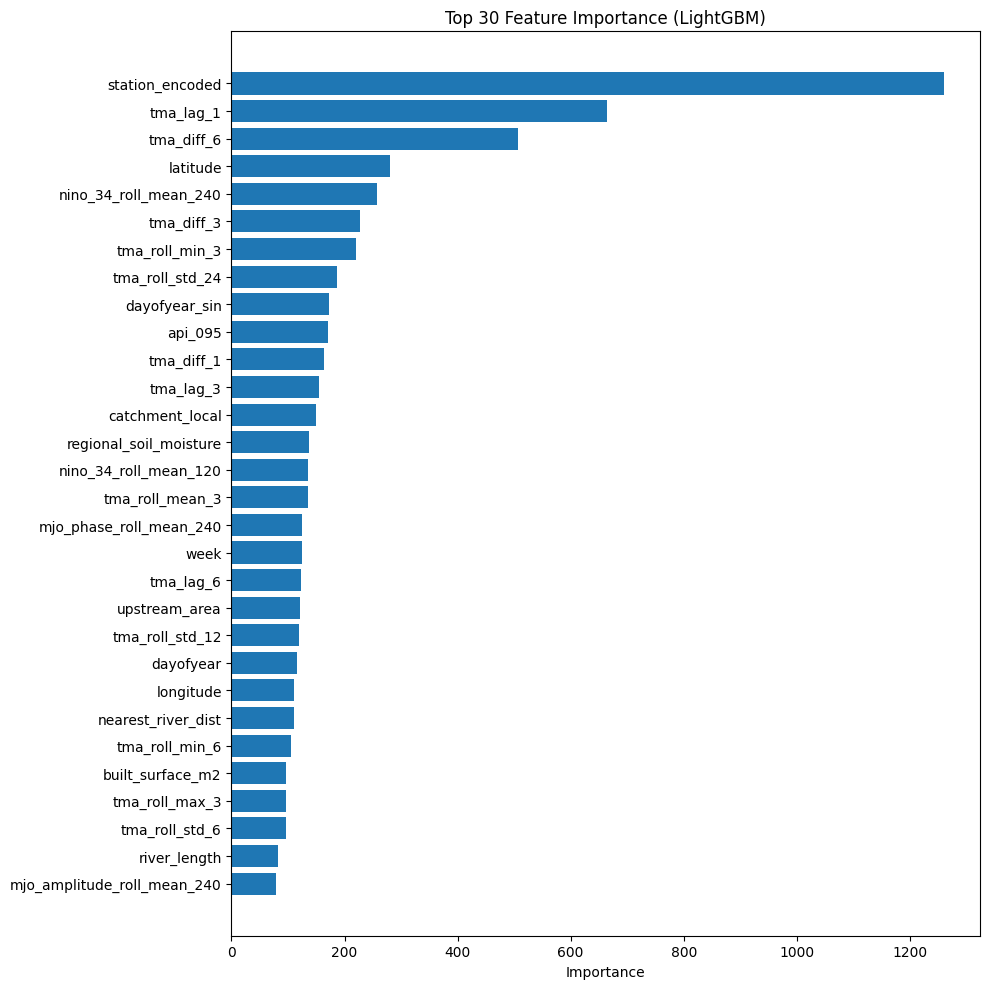

In [14]:
# Feature importance from best model
best_model_name = comparison.iloc[0]['model']
best_results = all_results[best_model_name]

if best_results['feature_importance'] is not None and not best_results['feature_importance'].empty:
    feat_imp = best_results['feature_importance'].head(30)
    plt.figure(figsize=(10, 10))
    plt.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1])
    plt.title(f'Top 30 Feature Importance ({best_model_name})')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f'Feature importance not available for {best_model_name}')


### Station-Level Diagnostics

Identify which stations contribute most to error.


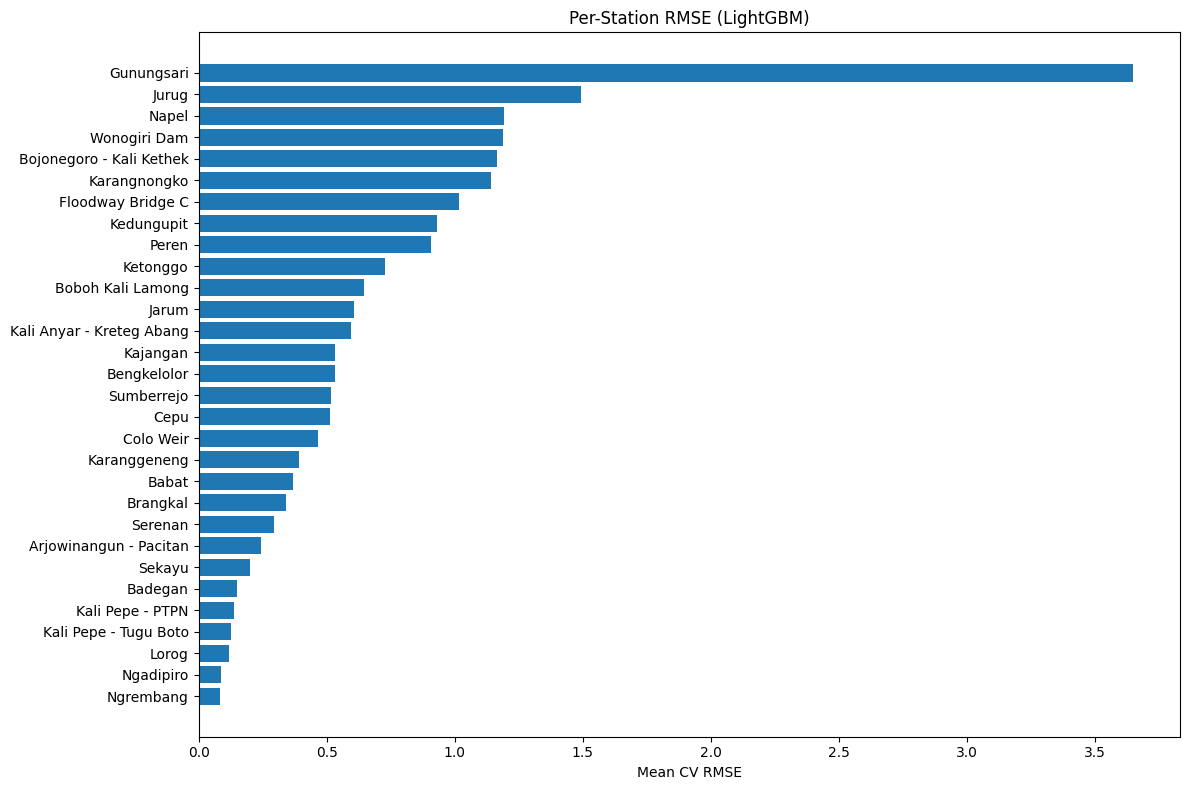


Worst 5 stations:
                     station  mean_rmse
10                Gunungsari   3.649778
12                     Jurug   1.494823
22                     Napel   1.191947
29              Wonogiri Dam   1.187143
5   Bojonegoro - Kali Kethek   1.165661


In [15]:
# Plot per-station RMSE from best model
station_metrics = best_results.get('station_metrics')
if station_metrics is not None:
    plt.figure(figsize=(12, 8))
    sm = station_metrics.sort_values('mean_rmse', ascending=True)
    plt.barh(sm['station'], sm['mean_rmse'])
    plt.xlabel('Mean CV RMSE')
    plt.title(f'Per-Station RMSE ({best_model_name})')
    plt.tight_layout()
    plt.show()
    print('\nWorst 5 stations:')
    print(station_metrics.head(5)[['station', 'mean_rmse']])


---
## Step 6: Train on Full Data & Generate Predictions

Train models on full training data (with holdout for early stopping), then generate predictions.


In [9]:
from src.train import train_full
from src.inference import predict_test, ensemble_predictions_by_rmse, ensemble_predictions, stacking_ensemble, build_submission

# Train best models on FULL training data
model_lgb_full, scaler_lgb, feats_lgb = train_full('lightgbm', master_train, feature_cols, cat_features)
model_cb_full, scaler_cb, feats_cb = train_full('catboost', master_train, feature_cols, cat_features)
model_xgb_full, scaler_xgb, feats_xgb = train_full('xgboost', master_train, feature_cols, cat_features)
model_rf_full, scaler_rf, feats_rf = train_full('random_forest', master_train, feature_cols, cat_features)
# model_bagging_full, scaler_bagging, feats_bagging = train_full('bagging', master_train, feature_cols, cat_features)


  [Feature Selection] Running fast fit for lightgbm...
  [Feature Selection] Selected 100 / 149 features.
Training lightgbm on full data with holdout:
  Train: 75957 rows, Holdout: 8439 rows
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 0.703631	valid's rmse: 0.301461
[400]	train's rmse: 0.616718	valid's rmse: 0.284506
[600]	train's rmse: 0.578149	valid's rmse: 0.275381
[800]	train's rmse: 0.555757	valid's rmse: 0.267696
[1000]	train's rmse: 0.539842	valid's rmse: 0.260816
[1200]	train's rmse: 0.52768	valid's rmse: 0.25648
[1400]	train's rmse: 0.516834	valid's rmse: 0.253467
[1600]	train's rmse: 0.507151	valid's rmse: 0.251018
[1800]	train's rmse: 0.498393	valid's rmse: 0.24875
[2000]	train's rmse: 0.489685	valid's rmse: 0.246754
[2200]	train's rmse: 0.481488	valid's rmse: 0.245265
[2400]	train's rmse: 0.473568	valid's rmse: 0.243817
[2600]	train's rmse: 0.465765	valid's rmse: 0.242462
[2800]	train's rmse: 0.458234	valid's rmse: 0.241354
[3000]	train

You should provide test set for use best model. use_best_model parameter has been switched to false value.


0:	learn: 0.9859135	total: 303ms	remaining: 30s
99:	learn: 0.5236360	total: 16.4s	remaining: 0us
  [Feature Selection] Selected 97 / 149 features.
Training catboost on full data with holdout:
  Train: 75957 rows, Holdout: 8439 rows
0:	learn: 0.9869754	test: 0.4468796	best: 0.4468796 (0)	total: 52.5ms	remaining: 8m 45s
200:	learn: 0.4099032	test: 0.3112635	best: 0.3109517 (199)	total: 12.3s	remaining: 9m 57s
400:	learn: 0.2961179	test: 0.2799313	best: 0.2799313 (400)	total: 24.1s	remaining: 9m 36s
600:	learn: 0.2348715	test: 0.2594496	best: 0.2594496 (600)	total: 35.7s	remaining: 9m 17s
800:	learn: 0.1971440	test: 0.2450826	best: 0.2450826 (800)	total: 46.8s	remaining: 8m 57s
1000:	learn: 0.1695199	test: 0.2351847	best: 0.2351847 (1000)	total: 57.4s	remaining: 8m 35s
1200:	learn: 0.1495360	test: 0.2275312	best: 0.2275161 (1198)	total: 1m 9s	remaining: 8m 31s
1400:	learn: 0.1341651	test: 0.2219803	best: 0.2219803 (1400)	total: 1m 21s	remaining: 8m 18s
1600:	learn: 0.1222461	test: 0.21660

In [10]:
# Ensure test feature columns match train
test_feature_cols = [c for c in feature_cols if c in master_test_featured.columns]
missing_cols = [c for c in feature_cols if c not in master_test_featured.columns]
print(f'Test features available: {len(test_feature_cols)} / {len(feature_cols)}')
if missing_cols:
    print(f'Missing in test: {missing_cols}')

# Generate predictions using model-specific features and scaler
preds_lgb = predict_test(model_lgb_full, master_test_featured, feats_lgb, scaler=scaler_lgb)
preds_cb = predict_test(model_cb_full, master_test_featured, feats_cb, scaler=scaler_cb)
preds_xgb = predict_test(model_xgb_full, master_test_featured, feats_xgb, scaler=scaler_xgb)
preds_rf = predict_test(model_rf_full, master_test_featured, feats_rf, scaler=scaler_rf)
# preds_bagging = predict_test(model_bagging_full, master_test_featured, feats_bagging, scaler=scaler_bagging)

print('\nPrediction stats:')
for name, preds in [('LightGBM', preds_lgb), ('CatBoost', preds_cb), ('XGBoost', preds_xgb), ('Random Forest', preds_rf)]:
    s = preds.tma_mdpl
    print(f'  {name}: mean={s.mean():.2f}, std={s.std():.2f}, min={s.min():.2f}, max={s.max():.2f}')


Test features available: 149 / 149

Prediction stats:
  LightGBM: mean=54.81, std=46.35, min=0.90, max=143.65
  CatBoost: mean=48.64, std=46.82, min=0.00, max=143.01
  XGBoost: mean=68.72, std=46.27, min=2.71, max=165.43
  Random Forest: mean=55.45, std=46.49, min=0.75, max=143.90


### Ensemble Strategies

We use three ensemble strategies across the models (Gradient Boosting, Random Forests, Bagging):
1. **Voting (Simple Average)** — equal weights across all models
2. **Inverse-RMSE weighted average** — weights based on CV performance
3. **Stacking with Ridge regression** — learns optimal combination from OOF predictions


In [ ]:
all_preds_dict = {
    'LightGBM': preds_lgb,
    'CatBoost': preds_cb,
    'XGBoost': preds_xgb,
    'Random Forest': preds_rf
    # 'Bagging': preds_bagging,
}

# 1. Voting ensemble (Simple average)
ensemble_voting = ensemble_predictions(all_preds_dict, weights=None)


In [ ]:
# 2. Inverse-RMSE weighted ensemble
cv_rmses = {
    'LightGBM': results_lgb['mean_metrics']['rmse'],
    'CatBoost': results_cb['mean_metrics']['rmse'],
    'XGBoost': results_xgb['mean_metrics']['rmse'],
    'Random Forest': results_rf['mean_metrics']['rmse']
    # 'Bagging': results_bagging['mean_metrics']['rmse'],
}
print('CV RMSE scores:')
for name, rmse in cv_rmses.items():
    print(f'  {name}: {rmse:.6f}')

ensemble_weighted = ensemble_predictions_by_rmse(
    predictions_dict=all_preds_dict,
    cv_rmses=cv_rmses,
)


In [ ]:
# 3. Stacking ensemble with Ridge meta-model
# Align OOF predictions
oof_lgb = results_lgb['oof_predictions']
oof_cb = results_cb['oof_predictions']
oof_xgb = results_xgb['oof_predictions']
oof_rf = results_rf['oof_predictions']
# oof_bagging = results_bagging['oof_predictions']

try:
    ensemble_stacked = stacking_ensemble(
        oof_predictions={
            'LightGBM': oof_lgb['predicted'].values,
            'CatBoost': oof_cb['predicted'].values,
            'XGBoost': oof_xgb['predicted'].values,
            'Random Forest': oof_rf['predicted'].values
            # 'Bagging': oof_bagging['predicted'].values,
        },
        test_predictions=all_preds_dict,
        y_true=oof_lgb['actual'],
    )
except Exception as e:
    print(f'Stacking failed: {e}')
    print('Using weighted ensemble instead.')
    ensemble_stacked = ensemble_weighted.copy()


In [11]:
# Save all submissions
# build_submission(ensemble_voting, filename='submission_ensemble_voting_v2.csv')
# build_submission(ensemble_weighted, filename='submission_ensemble_weighted_v2.csv')
# build_submission(ensemble_stacked, filename='submission_ensemble_stacked_v2.csv')

# Individual model submissions
build_submission(preds_lgb, filename='submission_lgb_v2.csv')
build_submission(preds_cb, filename='submission_cb_v2.csv')
build_submission(preds_xgb, filename='submission_xgb_v2.csv')
build_submission(preds_rf, filename='submission_rf_v2.csv')
# build_submission(preds_bagging, filename='submission_bagging_v2.csv')

print('\n' + '='*60)
print('All submissions saved!')
print('='*60)


Submission saved -> D:\Lomba\SSDS\Repo\SSDS_Dikeri-Leon\fayadh\outputs\submission_lgb_v2.csv
  Shape: (21780, 2)
  TMA stats: mean=54.812, std=46.347, min=0.896, max=143.653
Submission saved -> D:\Lomba\SSDS\Repo\SSDS_Dikeri-Leon\fayadh\outputs\submission_cb_v2.csv
  Shape: (21780, 2)
  TMA stats: mean=48.644, std=46.821, min=0.000, max=143.008
Submission saved -> D:\Lomba\SSDS\Repo\SSDS_Dikeri-Leon\fayadh\outputs\submission_xgb_v2.csv
  Shape: (21780, 2)
  TMA stats: mean=68.719, std=46.267, min=2.713, max=165.431
Submission saved -> D:\Lomba\SSDS\Repo\SSDS_Dikeri-Leon\fayadh\outputs\submission_rf_v2.csv
  Shape: (21780, 2)
  TMA stats: mean=55.453, std=46.492, min=0.750, max=143.903

All submissions saved!


---
## Step 7: Experiment Log

Track all experiments for reproducibility.


In [ ]:
from src.utils import load_experiment_log

exp_log = load_experiment_log()
if not exp_log.empty:
    display(exp_log)
else:
    print('No experiments logged yet.')


---
## Step 8: Deep Learning — TabNet (Optional)

TabNet uses sequential attention for feature selection. Requires `pip install pytorch-tabnet`.


In [ ]:
# Run TabNet (requires pytorch-tabnet: pip install pytorch-tabnet)
try:
    results_tabnet = run_experiment(
        exp_id='DL_01_v2',
        model_name='tabnet',
        df=master_train,
        feature_cols=feature_cols,
        feature_desc='All_v2_TabNet',
        cv=cv,
        categorical_features=cat_features,
        save_model=False,
        verbose=True
    )
    print(f"\nTabNet CV RMSE: {results_tabnet['mean_metrics']['rmse']:.6f}")
except Exception as e:
    print(f'TabNet not available: {e}')
    print('Install with: pip install pytorch-tabnet')
